## Imports and Setup

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import pickle
import json
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

# Configuration
DATA_PATH = '../data/raw'
PROCESSED_PATH = '../data/processed'
SPLITS_PATH = '../data/splits'
GOOD_PATH = os.path.join(DATA_PATH, 'train_data/good')
BAD_PATH = os.path.join(DATA_PATH, 'train_data/bad')
TEST_GOOD = os.path.join(DATA_PATH, 'test_data/good')
TEST_BAD = os.path.join(DATA_PATH, 'test_data/bad')

# Create output directories
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(SPLITS_PATH, exist_ok=True)
os.makedirs(f'{PROCESSED_PATH}/healthy', exist_ok=True)
os.makedirs(f'{PROCESSED_PATH}/unhealthy', exist_ok=True)

print("✓ Setup complete")

✓ Setup complete


## Define Preprocessing Pipeline Class

In [5]:
class PreprocessingPipeline:
    """Robust preprocessing pipeline with logging and validation"""
    
    def __init__(self, target_size=(360, 360), normalization='minmax'):
        """
        Args:
            target_size: Target image resolution
            normalization: 'minmax' [0,1], 'standard' (z-score), or 'none'
        """
        self.target_size = target_size
        self.normalization = normalization
        self.metadata = {
            'target_size': target_size,
            'normalization': normalization,
            'processed_count': 0,
            'failed_count': 0,
            'stats': {}
        }
    
    def validate_image(self, img_path: str) -> bool:
        """Check if image is valid and can be processed"""
        try:
            if not os.path.exists(img_path):
                return False
            
            img = cv2.imread(img_path)
            if img is None:
                return False
            
            # Check dimensions
            if len(img.shape) != 3 or img.shape[2] != 3:
                return False
            
            # Check if image is too small or too large
            h, w = img.shape[:2]
            if h < 100 or w < 100 or h > 2000 or w > 2000:
                return False
            
            return True
        except Exception as e:
            print(f"Error validating {img_path}: {e}")
            return False
    
    def resize_image(self, img: np.ndarray, method='cv2.INTER_AREA') -> np.ndarray:
        """Resize image with specified interpolation"""
        if method == 'cv2.INTER_AREA':
            resized = cv2.resize(img, self.target_size, interpolation=cv2.INTER_AREA)
        elif method == 'cv2.INTER_LINEAR':
            resized = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
        elif method == 'cv2.INTER_CUBIC':
            resized = cv2.resize(img, self.target_size, interpolation=cv2.INTER_CUBIC)
        else:
            resized = cv2.resize(img, self.target_size)
        
        return resized
    
    def normalize_image(self, img: np.ndarray) -> np.ndarray:
        """Normalize image pixel values"""
        img_float = img.astype(np.float32)
        
        if self.normalization == 'minmax':
            # Scale to [0, 1]
            img_normalized = img_float / 255.0
        
        elif self.normalization == 'standard':
            # Z-score normalization per channel
            img_normalized = np.zeros_like(img_float)
            for channel in range(3):
                mean = img_float[:, :, channel].mean()
                std = img_float[:, :, channel].std()
                img_normalized[:, :, channel] = (img_float[:, :, channel] - mean) / (std + 1e-7)
        
        elif self.normalization == 'none':
            img_normalized = img_float
        
        return img_normalized
    
    def apply_clahe(self, img: np.ndarray, clip_limit=2.0, tile_size=(8, 8)) -> np.ndarray:
        """Apply Contrast Limited Adaptive Histogram Equalization"""
        # Convert to LAB color space for better contrast enhancement
        lab = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
        l_clahe = clahe.apply(l)
        
        lab_clahe = cv2.merge([l_clahe, a, b])
        img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        
        return img_clahe.astype(np.float32) / 255.0
    
    def remove_noise(self, img: np.ndarray, method='bilateral') -> np.ndarray:
        """Remove noise from image"""
        img_uint8 = (img * 255).astype(np.uint8) if img.max() <= 1 else img.astype(np.uint8)
        
        if method == 'bilateral':
            # Bilateral filter preserves edges while smoothing
            denoised = cv2.bilateralFilter(img_uint8, 9, 75, 75)
        elif method == 'gaussian':
            denoised = cv2.GaussianBlur(img_uint8, (5, 5), 0)
        elif method == 'median':
            denoised = cv2.medianBlur(img_uint8, 5)
        else:
            denoised = img_uint8
        
        return denoised.astype(np.float32) / 255.0
    
    def preprocess(self, img_path: str, apply_clahe=True, remove_noise=True) -> Tuple[np.ndarray, dict]:
        """
        Complete preprocessing pipeline
        
        Returns:
            - Preprocessed image
            - Metadata dict with preprocessing info
        """
        metadata = {'path': img_path, 'success': False}
        
        try:
            # Validate
            if not self.validate_image(img_path):
                metadata['error'] = 'Invalid image'
                return None, metadata
            
            # Load
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            metadata['original_shape'] = img_rgb.shape
            
            # Convert to float and normalize to [0, 1]
            img_float = img_rgb.astype(np.float32) / 255.0
            
            # Remove noise
            if remove_noise:
                img_float = self.remove_noise(img_float, method='bilateral')
                metadata['noise_removed'] = True
            
            # Apply CLAHE for contrast enhancement
            if apply_clahe:
                img_float = self.apply_clahe(img_float)
                metadata['clahe_applied'] = True
            
            # Resize
            img_resized = self.resize_image(img_float)
            metadata['resized_to'] = self.target_size
            
            # Normalize pixel values
            img_normalized = self.normalize_image(img_resized)
            metadata['normalization'] = self.normalization
            
            # Calculate statistics
            metadata['mean'] = [float(img_normalized[:, :, i].mean()) for i in range(3)]
            metadata['std'] = [float(img_normalized[:, :, i].std()) for i in range(3)]
            metadata['min'] = float(img_normalized.min())
            metadata['max'] = float(img_normalized.max())
            
            metadata['success'] = True
            self.metadata['processed_count'] += 1
            
            return img_normalized, metadata
        
        except Exception as e:
            metadata['error'] = str(e)
            self.metadata['failed_count'] += 1
            return None, metadata

## Preprocess All Images

In [6]:
def load_image_paths(directory):
    """Load all image paths"""
    paths = []
    for file in os.listdir(directory):
        if file.endswith('.png'):
            paths.append(os.path.join(directory, file))
    return sorted(paths)

# Load paths
good_images = load_image_paths(GOOD_PATH)
bad_images = load_image_paths(BAD_PATH)
test_good = load_image_paths(TEST_GOOD)
test_bad = load_image_paths(TEST_BAD)

print(f"Total images to process: {len(good_images) + len(bad_images) + len(test_good) + len(test_bad)}")

# Initialize pipeline
pipeline = PreprocessingPipeline(target_size=(360, 360), normalization='minmax')

# Process training data
all_metadata = []
processed_images_healthy = []
processed_images_unhealthy = []

print("\nProcessing HEALTHY images...")
for i, path in enumerate(good_images):
    img, meta = pipeline.preprocess(path, apply_clahe=True, remove_noise=True)
    if img is not None:
        processed_images_healthy.append(img)
        all_metadata.append({'class': 'healthy', **meta})
        
        # Save preprocessed image
        output_path = os.path.join(PROCESSED_PATH, 'healthy', f'{i:04d}.npy')
        np.save(output_path, img)
    
    if (i + 1) % 50 == 0:
        print(f"  Processed {i + 1}/{len(good_images)}")

print("\nProcessing UNHEALTHY images...")
for i, path in enumerate(bad_images):
    img, meta = pipeline.preprocess(path, apply_clahe=True, remove_noise=True)
    if img is not None:
        processed_images_unhealthy.append(img)
        all_metadata.append({'class': 'unhealthy', **meta})
        
        # Save preprocessed image
        output_path = os.path.join(PROCESSED_PATH, 'unhealthy', f'{i:04d}.npy')
        np.save(output_path, img)
    
    if (i + 1) % 50 == 0:
        print(f"  Processed {i + 1}/{len(bad_images)}")

print(f"\n✓ Processed {pipeline.metadata['processed_count']} images")
print(f"✗ Failed {pipeline.metadata['failed_count']} images")

# Save metadata
metadata_df = pd.DataFrame(all_metadata)
metadata_df.to_csv(f'{PROCESSED_PATH}/preprocessing_metadata.csv', index=False)
print(f"✓ Saved metadata to {PROCESSED_PATH}/preprocessing_metadata.csv")

Total images to process: 412

Processing HEALTHY images...
  Processed 50/135
  Processed 100/135

Processing UNHEALTHY images...
  Processed 50/265
  Processed 100/265
  Processed 150/265
  Processed 200/265
  Processed 250/265

✓ Processed 400 images
✗ Failed 0 images
✓ Saved metadata to ../data/processed/preprocessing_metadata.csv


## Visualize Preprocessing Effects

Comparing preprocessing on Healthy image:


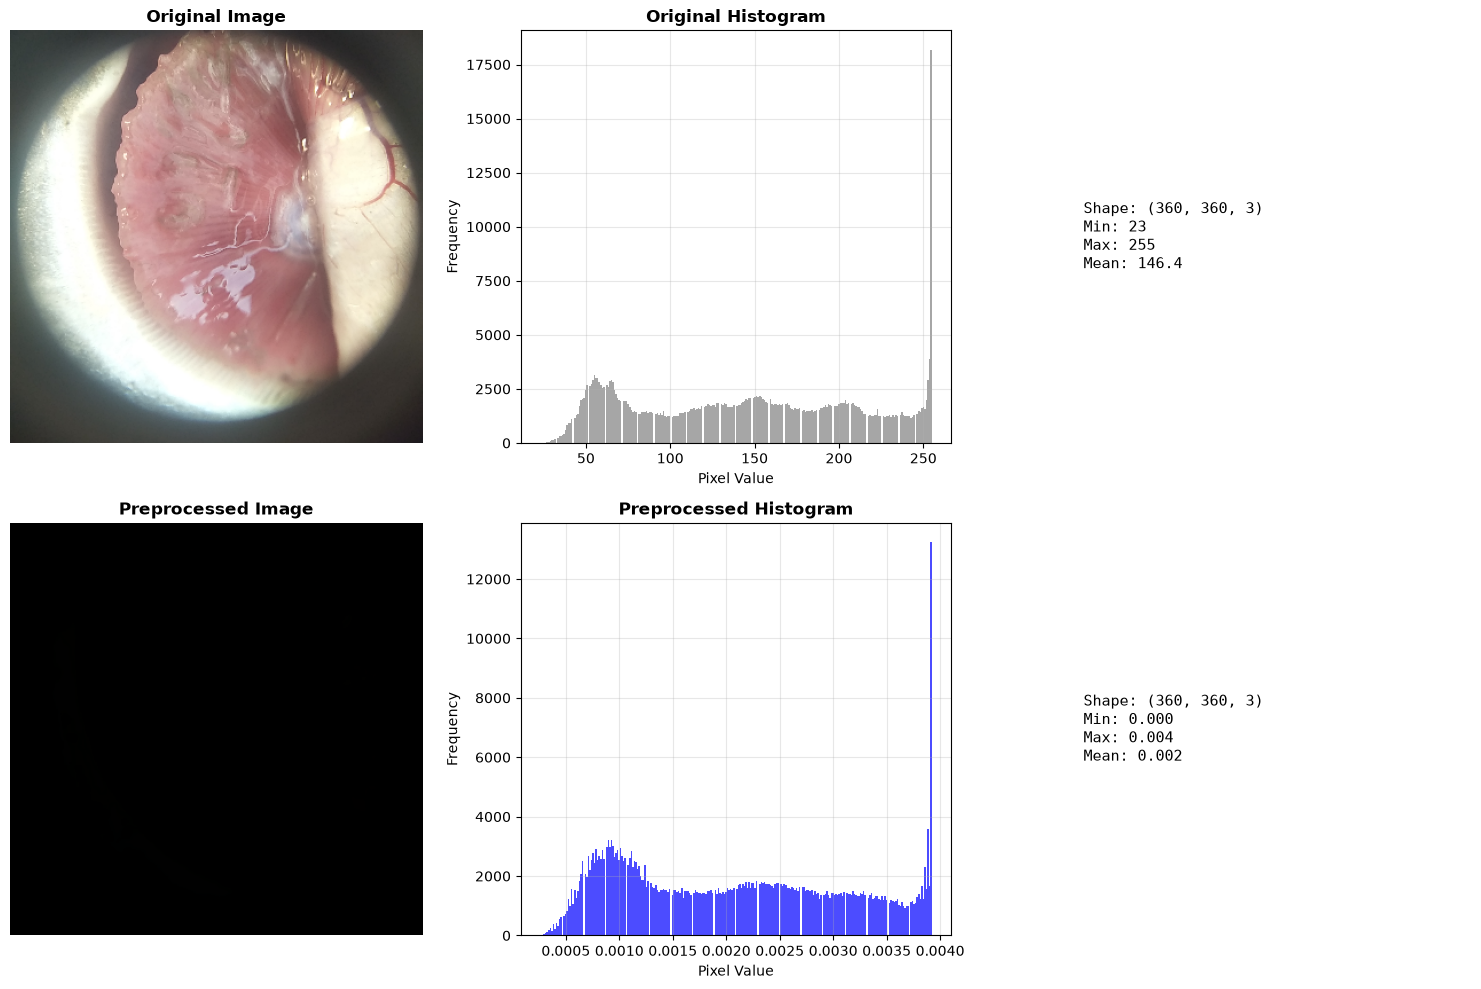


Comparing preprocessing on Unhealthy image:


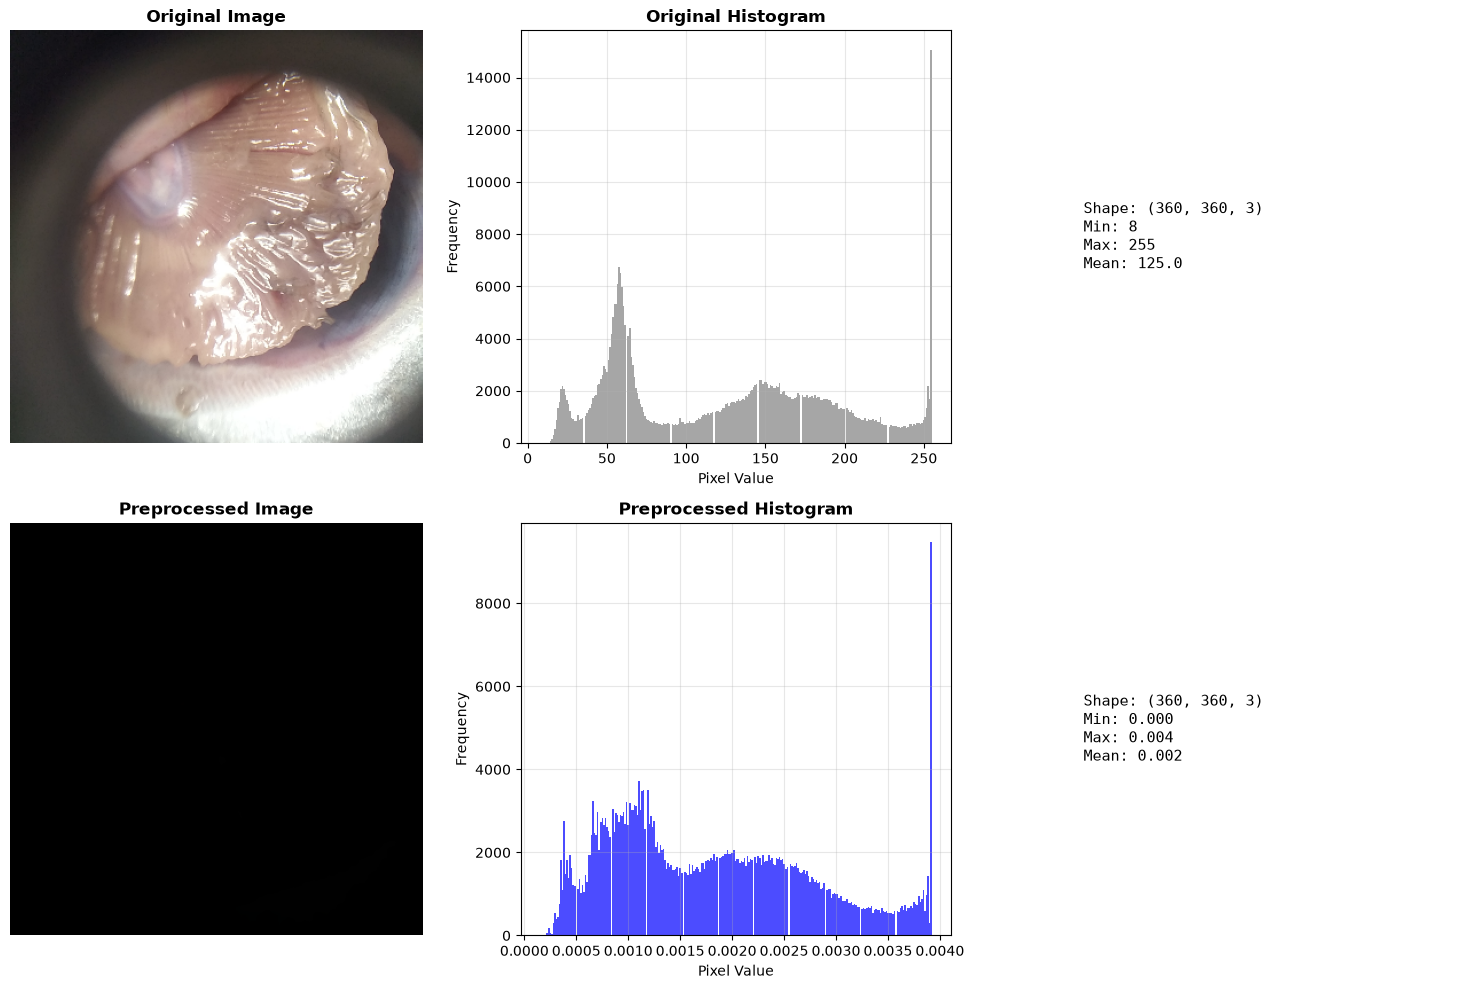

In [7]:
def compare_preprocessing(img_path, pipeline):
    """Show before/after preprocessing"""
    
    # Original
    img_orig = cv2.imread(img_path)
    img_orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    
    # Preprocessed
    img_proc, _ = pipeline.preprocess(img_path, apply_clahe=True, remove_noise=True)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original
    axes[0, 0].imshow(img_orig_rgb)
    axes[0, 0].set_title('Original Image', fontweight='bold', fontsize=12)
    axes[0, 0].axis('off')
    
    axes[0, 1].hist(img_orig_rgb.flatten(), bins=256, alpha=0.7, color='gray')
    axes[0, 1].set_title('Original Histogram', fontweight='bold')
    axes[0, 1].set_xlabel('Pixel Value')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(alpha=0.3)
    
    axes[0, 2].text(0.1, 0.5, f'Shape: {img_orig_rgb.shape}\nMin: {img_orig_rgb.min()}\nMax: {img_orig_rgb.max()}\nMean: {img_orig_rgb.mean():.1f}',
                    fontsize=11, verticalalignment='center', family='monospace')
    axes[0, 2].axis('off')
    
    # Preprocessed
    img_proc_display = np.clip(img_proc, 0, 1)  # Clip for visualization
    axes[1, 0].imshow(img_proc_display)
    axes[1, 0].set_title('Preprocessed Image', fontweight='bold', fontsize=12)
    axes[1, 0].axis('off')
    
    axes[1, 1].hist(img_proc.flatten(), bins=256, alpha=0.7, color='blue')
    axes[1, 1].set_title('Preprocessed Histogram', fontweight='bold')
    axes[1, 1].set_xlabel('Pixel Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(alpha=0.3)
    
    axes[1, 2].text(0.1, 0.5, f'Shape: {img_proc.shape}\nMin: {img_proc.min():.3f}\nMax: {img_proc.max():.3f}\nMean: {img_proc.mean():.3f}',
                    fontsize=11, verticalalignment='center', family='monospace')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('../results/02_preprocessing_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Compare on sample images
sample_good = good_images[0]
sample_bad = bad_images[0]

print("Comparing preprocessing on Healthy image:")
compare_preprocessing(sample_good, pipeline)

print("\nComparing preprocessing on Unhealthy image:")
compare_preprocessing(sample_bad, pipeline)

## Visualize Multiple Preprocessing Steps

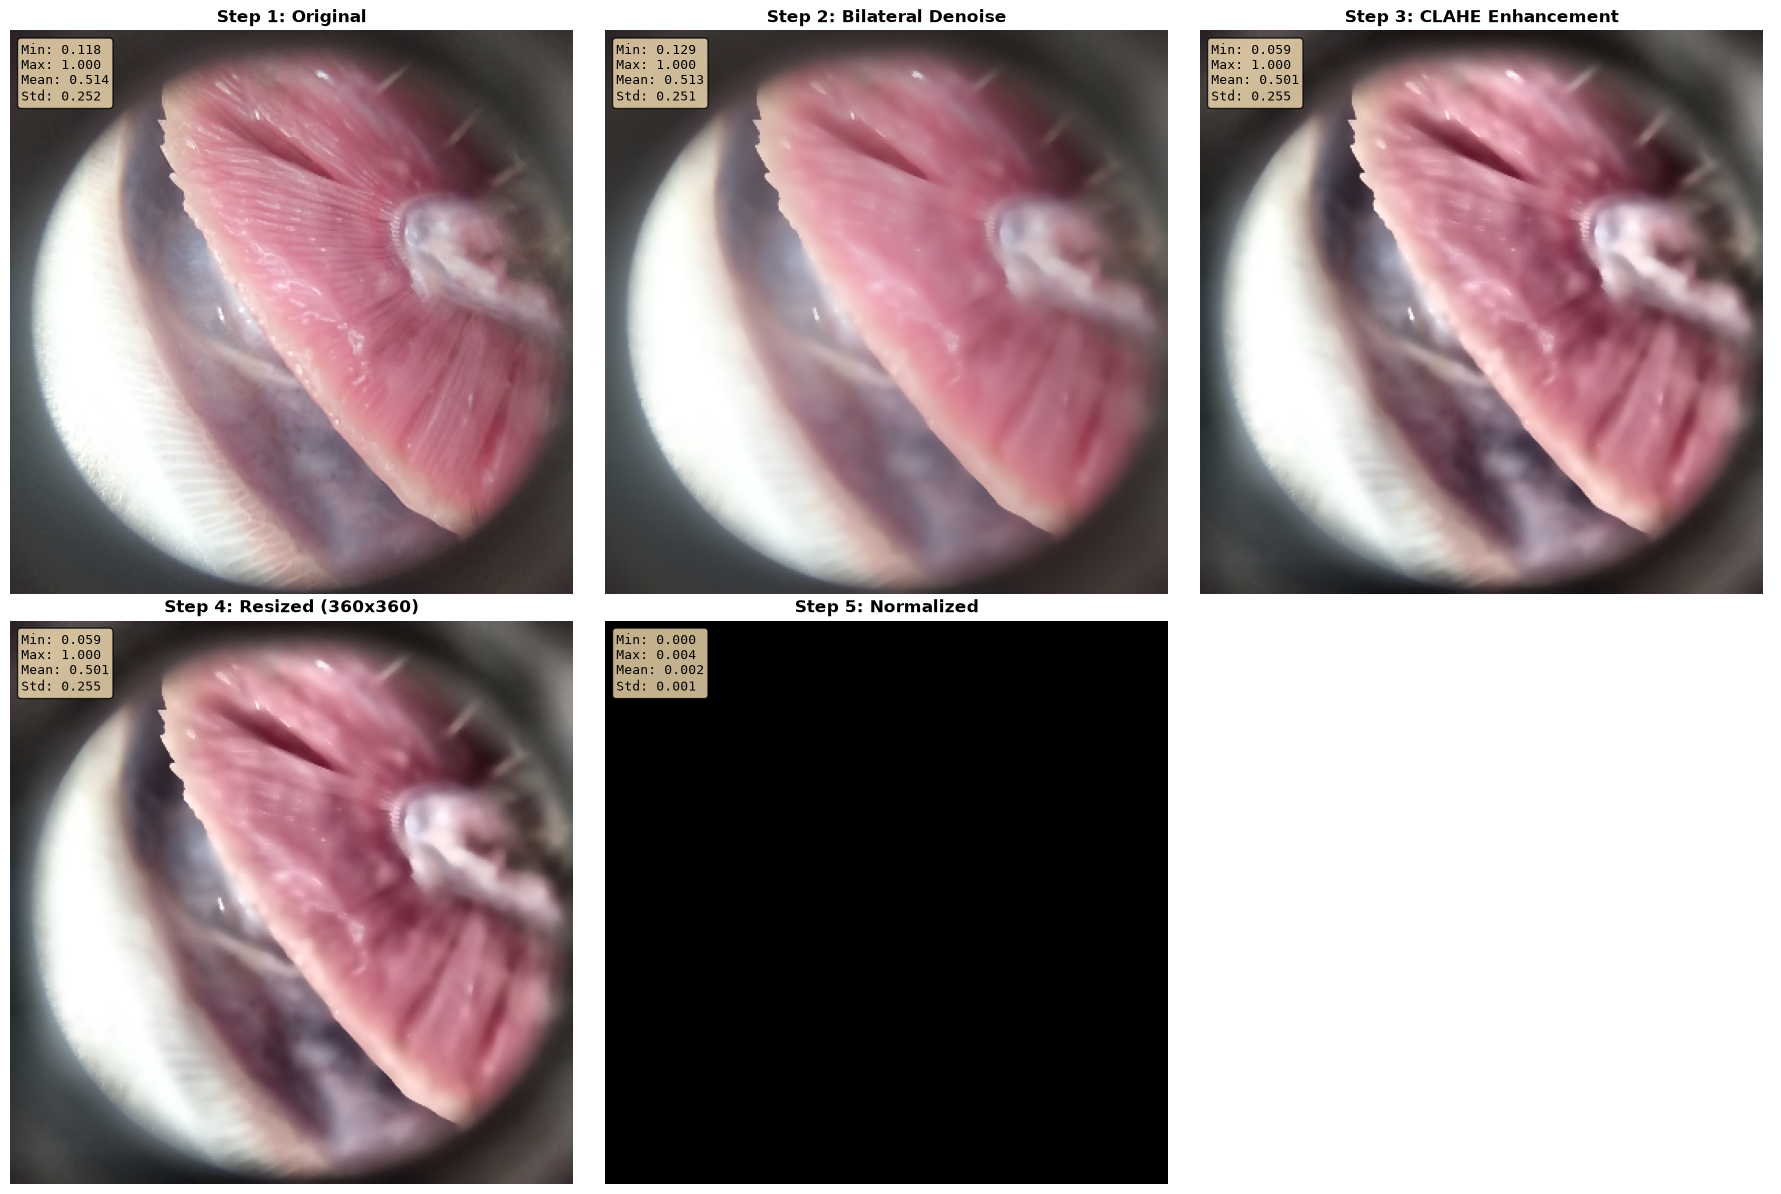

In [8]:
def visualize_preprocessing_steps(img_path):
    """Show each preprocessing step individually"""
    
    pipeline = PreprocessingPipeline(target_size=(360, 360), normalization='minmax')
    
    # Step 1: Original
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_float = img_rgb.astype(np.float32) / 255.0
    
    # Step 2: Noise removal
    img_denoised = pipeline.remove_noise(img_float, method='bilateral')
    
    # Step 3: CLAHE
    img_clahe = pipeline.apply_clahe(img_denoised)
    
    # Step 4: Resize
    img_resized = pipeline.resize_image(img_clahe)
    
    # Step 5: Normalize
    img_normalized = pipeline.normalize_image(img_resized)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    steps = [
        (img_float, 'Step 1: Original'),
        (img_denoised, 'Step 2: Bilateral Denoise'),
        (img_clahe, 'Step 3: CLAHE Enhancement'),
        (img_resized, 'Step 4: Resized (360x360)'),
        (img_normalized, 'Step 5: Normalized'),
    ]
    
    for idx, (img_step, title) in enumerate(steps):
        row, col = divmod(idx, 3)
        
        # Clip for visualization
        img_display = np.clip(img_step, 0, 1) if img_step.max() <= 1 else img_step / 255.0
        
        axes[row, col].imshow(img_display)
        axes[row, col].set_title(title, fontweight='bold', fontsize=12)
        axes[row, col].axis('off')
        
        # Add statistics
        stats_text = f'Min: {img_step.min():.3f}\nMax: {img_step.max():.3f}\nMean: {img_step.mean():.3f}\nStd: {img_step.std():.3f}'
        axes[row, col].text(0.02, 0.98, stats_text, transform=axes[row, col].transAxes,
                           fontsize=9, verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                           family='monospace')
    
    # Remove last empty subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('../results/02_preprocessing_steps.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_preprocessing_steps(good_images[5])

#### Why Each Step Matters:

`Denoise` - Remove artifacts from image acquisition

`CLAHE` - Enhance local contrast without over-saturation

`Resize` - Consistent input for model

`Normalize` - Scale pixel values to reasonable range

`Standardize` - Center and scale features across entire dataset

`Stratification` - Maintain class balance across splits

`No leakage` - Fit scaler only on training data

## Analyze Preprocessing Impact on Statistics

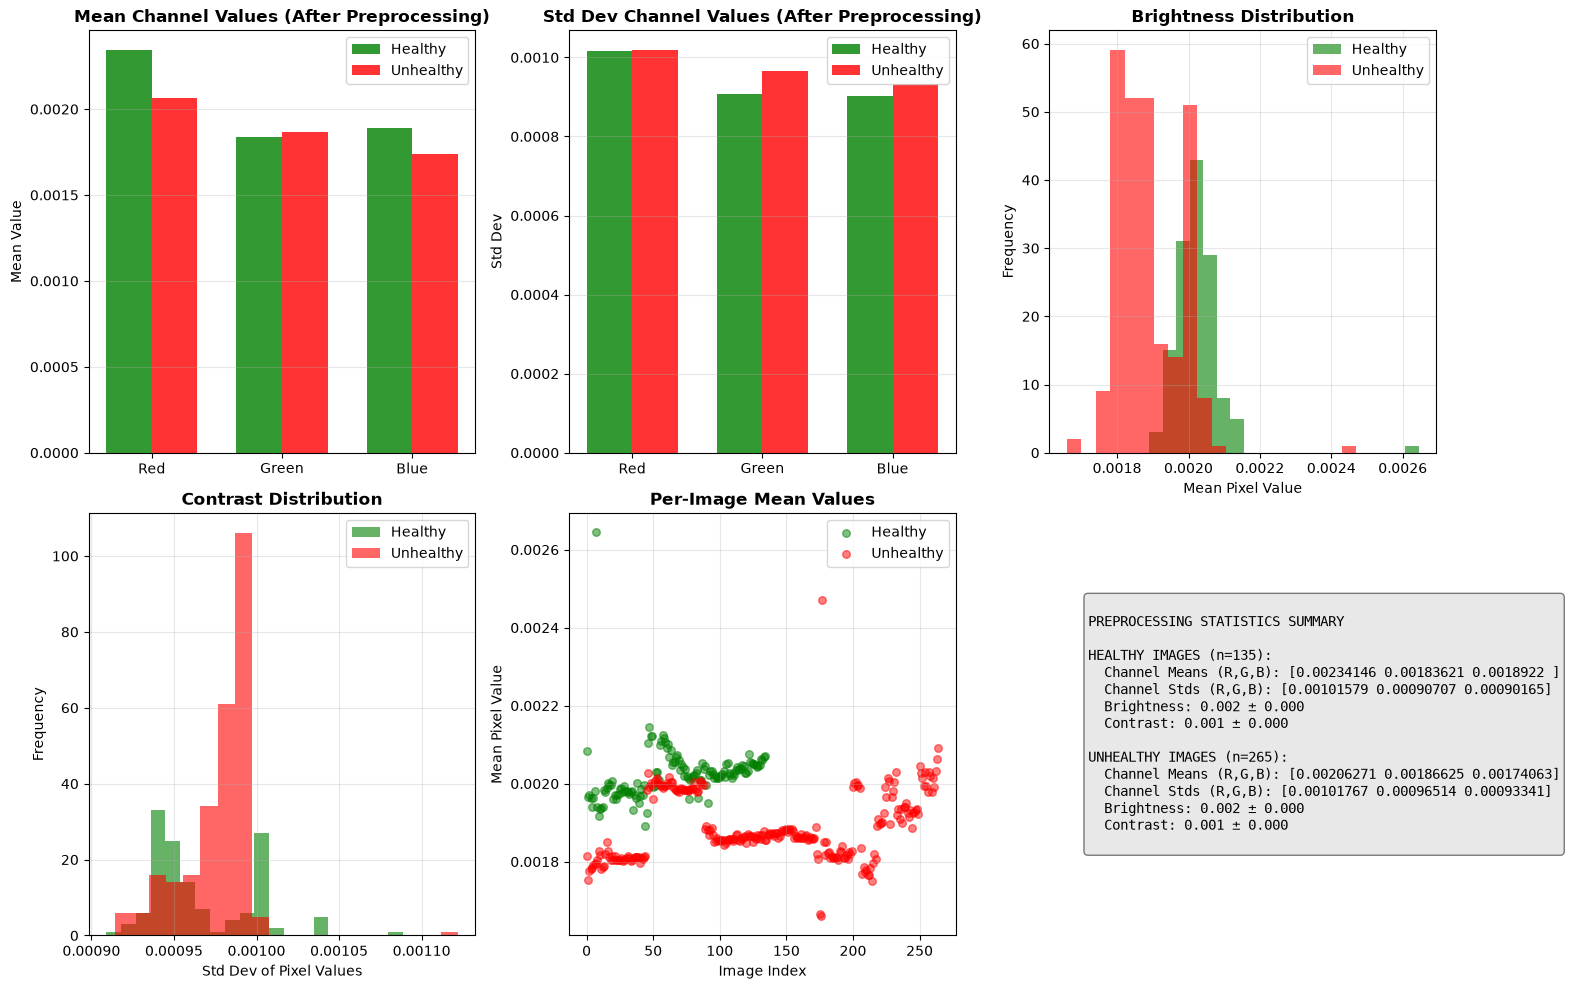

In [9]:
def analyze_preprocessing_stats(processed_images_healthy, processed_images_unhealthy):
    """Analyze how preprocessing affects image statistics"""
    
    healthy_array = np.array(processed_images_healthy)
    unhealthy_array = np.array(processed_images_unhealthy)
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # Mean values per channel
    healthy_means = np.array([healthy_array[:, :, :, i].mean() for i in range(3)])
    unhealthy_means = np.array([unhealthy_array[:, :, :, i].mean() for i in range(3)])
    
    x = np.arange(3)
    width = 0.35
    axes[0, 0].bar(x - width/2, healthy_means, width, label='Healthy', alpha=0.8, color='green')
    axes[0, 0].bar(x + width/2, unhealthy_means, width, label='Unhealthy', alpha=0.8, color='red')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(['Red', 'Green', 'Blue'])
    axes[0, 0].set_title('Mean Channel Values (After Preprocessing)', fontweight='bold')
    axes[0, 0].set_ylabel('Mean Value')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # Std values per channel
    healthy_stds = np.array([healthy_array[:, :, :, i].std() for i in range(3)])
    unhealthy_stds = np.array([unhealthy_array[:, :, :, i].std() for i in range(3)])
    
    axes[0, 1].bar(x - width/2, healthy_stds, width, label='Healthy', alpha=0.8, color='green')
    axes[0, 1].bar(x + width/2, unhealthy_stds, width, label='Unhealthy', alpha=0.8, color='red')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(['Red', 'Green', 'Blue'])
    axes[0, 1].set_title('Std Dev Channel Values (After Preprocessing)', fontweight='bold')
    axes[0, 1].set_ylabel('Std Dev')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Overall brightness distribution
    healthy_brightness = healthy_array.mean(axis=(1, 2, 3))
    unhealthy_brightness = unhealthy_array.mean(axis=(1, 2, 3))
    
    axes[0, 2].hist(healthy_brightness, bins=20, alpha=0.6, label='Healthy', color='green')
    axes[0, 2].hist(unhealthy_brightness, bins=20, alpha=0.6, label='Unhealthy', color='red')
    axes[0, 2].set_title('Brightness Distribution', fontweight='bold')
    axes[0, 2].set_xlabel('Mean Pixel Value')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()
    axes[0, 2].grid(alpha=0.3)
    
    # Contrast (std of entire image)
    healthy_contrast = healthy_array.std(axis=(1, 2, 3))
    unhealthy_contrast = unhealthy_array.std(axis=(1, 2, 3))
    
    axes[1, 0].hist(healthy_contrast, bins=20, alpha=0.6, label='Healthy', color='green')
    axes[1, 0].hist(unhealthy_contrast, bins=20, alpha=0.6, label='Unhealthy', color='red')
    axes[1, 0].set_title('Contrast Distribution', fontweight='bold')
    axes[1, 0].set_xlabel('Std Dev of Pixel Values')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Per-image statistics
    healthy_per_image_mean = [healthy_array[i].mean() for i in range(len(healthy_array))]
    unhealthy_per_image_mean = [unhealthy_array[i].mean() for i in range(len(unhealthy_array))]
    
    axes[1, 1].scatter(range(len(healthy_per_image_mean)), healthy_per_image_mean, 
                      alpha=0.5, label='Healthy', color='green', s=30)
    axes[1, 1].scatter(range(len(unhealthy_per_image_mean)), unhealthy_per_image_mean, 
                      alpha=0.5, label='Unhealthy', color='red', s=30)
    axes[1, 1].set_title('Per-Image Mean Values', fontweight='bold')
    axes[1, 1].set_xlabel('Image Index')
    axes[1, 1].set_ylabel('Mean Pixel Value')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    # Statistics summary
    summary_text = f"""
PREPROCESSING STATISTICS SUMMARY

HEALTHY IMAGES (n={len(healthy_array)}):
  Channel Means (R,G,B): {healthy_means}
  Channel Stds (R,G,B): {healthy_stds}
  Brightness: {healthy_brightness.mean():.3f} ± {healthy_brightness.std():.3f}
  Contrast: {healthy_contrast.mean():.3f} ± {healthy_contrast.std():.3f}

UNHEALTHY IMAGES (n={len(unhealthy_array)}):
  Channel Means (R,G,B): {unhealthy_means}
  Channel Stds (R,G,B): {unhealthy_stds}
  Brightness: {unhealthy_brightness.mean():.3f} ± {unhealthy_brightness.std():.3f}
  Contrast: {unhealthy_contrast.mean():.3f} ± {unhealthy_contrast.std():.3f}
    """
    
    axes[1, 2].text(0.1, 0.5, summary_text, transform=axes[1, 2].transAxes,
                   fontsize=10, verticalalignment='center', family='monospace',
                   bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('../results/02_preprocessing_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()

analyze_preprocessing_stats(processed_images_healthy, processed_images_unhealthy)

## Create Train/Val/Test Splits

In [10]:
from sklearn.model_selection import train_test_split

# Combine data
X_healthy = np.array(processed_images_healthy)
X_unhealthy = np.array(processed_images_unhealthy)

y_healthy = np.ones(len(X_healthy))
y_unhealthy = np.zeros(len(X_unhealthy))

X = np.vstack([X_healthy, X_unhealthy])
y = np.concatenate([y_healthy, y_unhealthy])

print(f"Total processed images: {len(X)}")
print(f"Healthy: {np.sum(y)}, Unhealthy: {len(y) - np.sum(y)}")

# First split: train+val (80%) and test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain+Val set: {len(X_train_val)}")
print(f"Test set: {len(X_test)}")

# Second split: train (80% of train_val) and val (20% of train_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print(f"\nTrain set: {len(X_train)}")
print(f"Val set: {len(X_val)}")
print(f"Test set: {len(X_test)}")

# Verify stratification
print(f"\nClass distribution in splits:")
print(f"Train - Healthy: {np.sum(y_train)}, Unhealthy: {len(y_train) - np.sum(y_train)}")
print(f"Val - Healthy: {np.sum(y_val)}, Unhealthy: {len(y_val) - np.sum(y_val)}")
print(f"Test - Healthy: {np.sum(y_test)}, Unhealthy: {len(y_test) - np.sum(y_test)}")

# Save splits
np.save(f'{SPLITS_PATH}/X_train.npy', X_train)
np.save(f'{SPLITS_PATH}/y_train.npy', y_train)
np.save(f'{SPLITS_PATH}/X_val.npy', X_val)
np.save(f'{SPLITS_PATH}/y_val.npy', y_val)
np.save(f'{SPLITS_PATH}/X_test.npy', X_test)
np.save(f'{SPLITS_PATH}/y_test.npy', y_test)

print(f"\n✓ Splits saved to {SPLITS_PATH}")

Total processed images: 400
Healthy: 135.0, Unhealthy: 265.0

Train+Val set: 320
Test set: 80

Train set: 256
Val set: 64
Test set: 80

Class distribution in splits:
Train - Healthy: 86.0, Unhealthy: 170.0
Val - Healthy: 22.0, Unhealthy: 42.0
Test - Healthy: 27.0, Unhealthy: 53.0

✓ Splits saved to ../data/splits


## Visualize Train/Val/Test Distribution

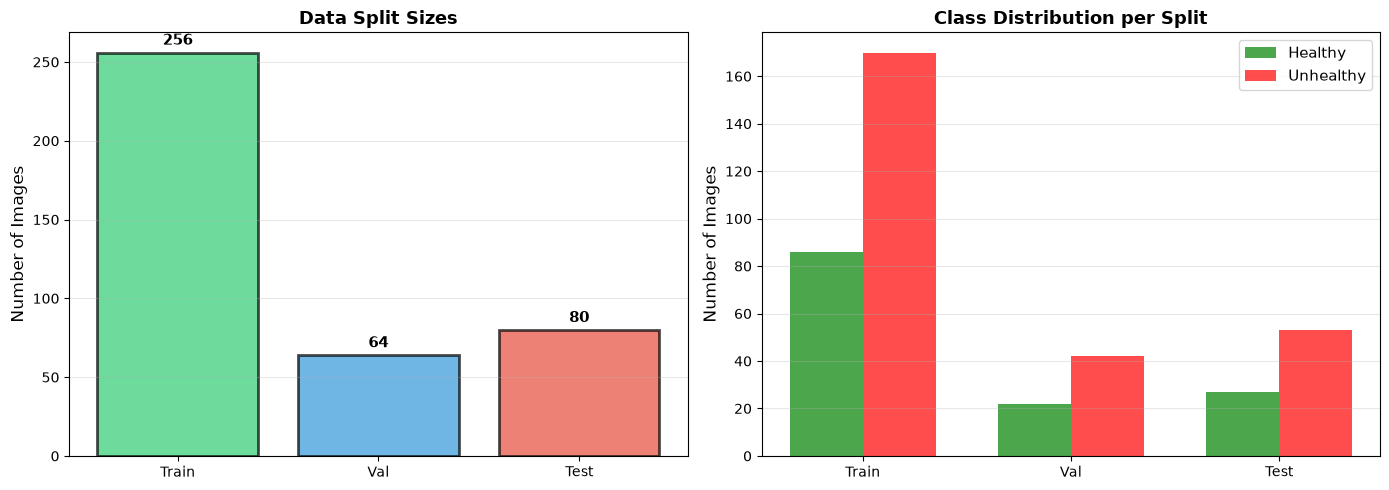

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split sizes
splits = ['Train', 'Val', 'Test']
sizes = [len(X_train), len(X_val), len(X_test)]
colors_splits = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].bar(splits, sizes, color=colors_splits, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Data Split Sizes', fontweight='bold', fontsize=13)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(sizes):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=11)

# Class distribution per split
train_healthy = np.sum(y_train)
train_unhealthy = len(y_train) - train_healthy
val_healthy = np.sum(y_val)
val_unhealthy = len(y_val) - val_healthy
test_healthy = np.sum(y_test)
test_unhealthy = len(y_test) - test_healthy

x = np.arange(3)
width = 0.35

healthy_counts = [train_healthy, val_healthy, test_healthy]
unhealthy_counts = [train_unhealthy, val_unhealthy, test_unhealthy]

axes[1].bar(x - width/2, healthy_counts, width, label='Healthy', color='green', alpha=0.7)
axes[1].bar(x + width/2, unhealthy_counts, width, label='Unhealthy', color='red', alpha=0.7)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_title('Class Distribution per Split', fontweight='bold', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/02_train_val_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

## Apply Standardization (Optional)

In [12]:
def standardize_dataset(X_train, X_val, X_test):
    """
    Standardize pixel values across all images
    Fit scaler on training data only to avoid data leakage
    """
    # Reshape for scaling
    n_train, h, w, c = X_train.shape
    n_val = X_val.shape[0]
    n_test = X_test.shape[0]
    
    # Reshape to 2D
    X_train_2d = X_train.reshape(-1, h*w*c)
    X_val_2d = X_val.reshape(-1, h*w*c)
    X_test_2d = X_test.reshape(-1, h*w*c)
    
    # Fit on training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_2d)
    X_val_scaled = scaler.transform(X_val_2d)
    X_test_scaled = scaler.transform(X_test_2d)
    
    # Reshape back
    X_train_scaled = X_train_scaled.reshape(n_train, h, w, c)
    X_val_scaled = X_val_scaled.reshape(n_val, h, w, c)
    X_test_scaled = X_test_scaled.reshape(n_test, h, w, c)
    
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

# Apply standardization
X_train_scaled, X_val_scaled, X_test_scaled, scaler = standardize_dataset(X_train, X_val, X_test)

# Save scaler for later use
import joblib
joblib.dump(scaler, f'{SPLITS_PATH}/standardization_scaler.pkl')

# Save standardized splits
np.save(f'{SPLITS_PATH}/X_train_scaled.npy', X_train_scaled)
np.save(f'{SPLITS_PATH}/X_val_scaled.npy', X_val_scaled)
np.save(f'{SPLITS_PATH}/X_test_scaled.npy', X_test_scaled)

print("✓ Standardization applied and saved")
print(f"Scaler mean: {scaler.mean_[:10]}...")  # Show first 10
print(f"Scaler scale: {scaler.scale_[:10]}...")  # Show first 10

✓ Standardization applied and saved
Scaler mean: [0.00063816 0.00058661 0.00056162 0.00064014 0.00058878 0.00056385
 0.00064398 0.00059094 0.00056691 0.00065197]...
Scaler scale: [0.00020763 0.0001929  0.0001907  0.00020773 0.0001908  0.00018875
 0.00020917 0.00019285 0.00019129 0.00021205]...


## Create Data Loader Class for Easy Access

In [ ]:

class DataLoader:
    """Simple data loader for easy batch processing"""
    
    def __init__(self, X, y, batch_size=32, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.current_idx = 0
        self.indices = np.arange(len(X))
        
        if shuffle:
            np.random.shuffle(self.indices)
    
    def __len__(self):
        """Return number of batches"""
        return int(np.ceil(len(self.X) / self.batch_size))
    
    def __iter__(self):
        self.current_idx = 0
        if self.shuffle:
            np.random.shuffle(self.indices)
        return self
    
    def __next__(self):
        if self.current_idx >= len(self.X):
            raise StopIteration
        
        batch_indices = self.indices[self.current_idx:self.current_idx + self.batch_size]
        batch_X = self.X[batch_indices]
        batch_y = self.y[batch_indices]
        
        self.current_idx += self.batch_size
        return batch_X, batch_y
    
    def get_all(self):
        """Return all data"""
        return self.X, self.y

# Create data loader
train_loader = DataLoader(X_train, y_train, batch_size=32, shuffle=True)

# Test data loader
print(f"Number of batches: {len(train_loader)}")
for batch_idx, (batch_X, batch_y) in enumerate(train_loader):
    print(f"Batch {batch_idx}: X shape = {batch_X.shape}, y shape = {batch_y.shape}")
    if batch_idx == 2:
        break

# Save data loader for later use
joblib.dump(train_loader, f'{SPLITS_PATH}/train_loader.pkl')
print("\n✓ Data loader created and saved")

Number of batches: 8
Batch 0: X shape = (32, 360, 360, 3), y shape = (32,)
Batch 1: X shape = (32, 360, 360, 3), y shape = (32,)
Batch 2: X shape = (32, 360, 360, 3), y shape = (32,)

✓ Data loader created and saved


## Create Preprocessing Configuration File

In [14]:
config = {
    'preprocessing': {
        'target_size': [360, 360],
        'normalization': 'minmax',
        'remove_noise': True,
        'noise_removal_method': 'bilateral',
        'apply_clahe': True,
        'clahe_clip_limit': 2.0,
        'clahe_tile_size': [8, 8],
    },
    'data_split': {
        'train_ratio': 0.64,  # 80% of 80%
        'val_ratio': 0.16,    # 20% of 80%
        'test_ratio': 0.20,   # 20%
        'stratified': True,
        'random_state': 42,
    },
    'standardization': {
        'method': 'StandardScaler',
        'fit_on': 'train_set_only',
    },
    'images_processed': {
        'healthy_train': int(np.sum(y_train)),
        'unhealthy_train': int(len(y_train) - np.sum(y_train)),
        'healthy_val': int(np.sum(y_val)),
        'unhealthy_val': int(len(y_val) - np.sum(y_val)),
        'healthy_test': int(np.sum(y_test)),
        'unhealthy_test': int(len(y_test) - np.sum(y_test)),
    }
}

# Save config
with open(f'{SPLITS_PATH}/preprocessing_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✓ Configuration saved to preprocessing_config.json")
print(json.dumps(config, indent=2))

✓ Configuration saved to preprocessing_config.json
{
  "preprocessing": {
    "target_size": [
      360,
      360
    ],
    "normalization": "minmax",
    "remove_noise": true,
    "noise_removal_method": "bilateral",
    "apply_clahe": true,
    "clahe_clip_limit": 2.0,
    "clahe_tile_size": [
      8,
      8
    ]
  },
  "data_split": {
    "train_ratio": 0.64,
    "val_ratio": 0.16,
    "test_ratio": 0.2,
    "stratified": true,
    "random_state": 42
  },
  "standardization": {
    "method": "StandardScaler",
    "fit_on": "train_set_only"
  },
  "images_processed": {
    "healthy_train": 86,
    "unhealthy_train": 170,
    "healthy_val": 22,
    "unhealthy_val": 42,
    "healthy_test": 27,
    "unhealthy_test": 53
  }
}


## Summary Report

In [16]:
summary_report = f"""
╔════════════════════════════════════════════════════════════════════╗
║          PREPROCESSING PIPELINE SUMMARY REPORT                    ║
╚════════════════════════════════════════════════════════════════════╝

PROCESSING STATISTICS:
  • Total images processed: {pipeline.metadata['processed_count']}
  • Failed images: {pipeline.metadata['failed_count']}
  • Success rate: {100*pipeline.metadata['processed_count']/(pipeline.metadata['processed_count']+pipeline.metadata['failed_count']):.1f}%

PREPROCESSING PIPELINE:
  1. ✓ Validation - Check image integrity
  2. ✓ Denoising - Bilateral filter for edge-preserving smoothing
  3. ✓ Contrast Enhancement - CLAHE for adaptive histogram equalization
  4. ✓ Resizing - All images to {config['preprocessing']['target_size']}
  5. ✓ Normalization - {config['preprocessing']['normalization']} scaling

DATA SPLITS:
  • Train set: {len(X_train)} images
    - Healthy: {int(np.sum(y_train))} ({100*np.sum(y_train)/len(y_train):.1f}%)
    - Unhealthy: {int(len(y_train) - np.sum(y_train))} ({100*(len(y_train) - np.sum(y_train))/len(y_train):.1f}%)
  
  • Validation set: {len(X_val)} images
    - Healthy: {int(np.sum(y_val))} ({100*np.sum(y_val)/len(y_val):.1f}%)
    - Unhealthy: {int(len(y_val) - np.sum(y_val))} ({100*(len(y_val) - np.sum(y_val))/len(y_val):.1f}%)
  
  • Test set: {len(X_test)} images
    - Healthy: {int(np.sum(y_test))} ({100*np.sum(y_test)/len(y_test):.1f}%)
    - Unhealthy: {int(len(y_test) - np.sum(y_test))} ({100*(len(y_test) - np.sum(y_test))/len(y_test):.1f}%)

DATA STATISTICS (After Preprocessing):
  • Image shape: {X_train[0].shape}
  • Value range: [{X_train.min():.3f}, {X_train.max():.3f}]
  • Train data mean: {X_train.mean():.3f}
  • Train data std: {X_train.std():.3f}

STANDARDIZATION:
  • Method: StandardScaler (fit on training data only)
  • Scaler saved: {SPLITS_PATH}/standardization_scaler.pkl

OUTPUT FILES:
  ✓ Processed images: {PROCESSED_PATH}/healthy/, {PROCESSED_PATH}/unhealthy/
  ✓ Train/val/test splits: {SPLITS_PATH}/X_train.npy, X_val.npy, X_test.npy
  ✓ Labels: {SPLITS_PATH}/y_train.npy, y_val.npy, y_test.npy
  ✓ Scaled versions: {SPLITS_PATH}/X_train_scaled.npy, etc.
  ✓ Configuration: {SPLITS_PATH}/preprocessing_config.json
  ✓ Metadata: {PROCESSED_PATH}/preprocessing_metadata.csv

RECOMMENDATIONS FOR NEXT STEPS:
  1. Use the preprocessed data for feature extraction in 03_feature_engineering.ipynb
  2. Try multiple feature extraction methods (pixels, histograms, textures, etc.)
  3. Build models with proper cross-validation using the created splits
  4. Monitor both train and val metrics to detect overfitting
  5. Perform error analysis on misclassified validation examples
"""

print(summary_report)

# Save report
with open('../results/02_preprocessing_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)
print(f"\n✓ Report saved to ../results/02_preprocessing_report.txt")


╔════════════════════════════════════════════════════════════════════╗
║          PREPROCESSING PIPELINE SUMMARY REPORT                    ║
╚════════════════════════════════════════════════════════════════════╝

PROCESSING STATISTICS:
  • Total images processed: 402
  • Failed images: 0
  • Success rate: 100.0%

PREPROCESSING PIPELINE:
  1. ✓ Validation - Check image integrity
  2. ✓ Denoising - Bilateral filter for edge-preserving smoothing
  3. ✓ Contrast Enhancement - CLAHE for adaptive histogram equalization
  4. ✓ Resizing - All images to [360, 360]
  5. ✓ Normalization - minmax scaling

DATA SPLITS:
  • Train set: 256 images
    - Healthy: 86 (33.6%)
    - Unhealthy: 170 (66.4%)

  • Validation set: 64 images
    - Healthy: 22 (34.4%)
    - Unhealthy: 42 (65.6%)

  • Test set: 80 images
    - Healthy: 27 (33.8%)
    - Unhealthy: 53 (66.2%)

DATA STATISTICS (After Preprocessing):
  • Image shape: (360, 360, 3)
  • Value range: [0.000, 0.004]
  • Train data mean: 0.002
  • Train 